In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('datasets/watchbase_data_featured_scrapy.csv')

In [5]:
df.head()

,Url,Brand,Model,Limited,CaseMaterialGrouped,Glass,Case Shape,CaseDiameterGrouped,WaterResistanceLevel,DialColorGrouped,DialHandsGrouped,Dial Indexes,LogPrice
0,https://watchbase.com/panerai/pocket-watches/p...,panerai,pocket watches,Yes,Gold Variants,Sapphire,Cushion,XXL,Basic,Black,Stick/Minimalist,Mixed,11.058811
1,https://watchbase.com/patek-philippe/cubitus/5...,patek philippe,cubitus,No,Steel,Sapphire,Square,XL,Basic,Blue,Stick/Minimalist,Stick / Dot,11.039412
2,https://watchbase.com/patek-philippe/cubitus/5...,patek philippe,cubitus,No,Platinum,Sapphire,Square,XL,Basic,Blue,Stick/Minimalist,Stick / Dot,11.405685
3,https://watchbase.com/patek-philippe/cubitus/5...,patek philippe,cubitus,No,Steel,Sapphire,Square,XL,Basic,Colorful,Stick/Minimalist,Stick / Dot,10.643542
4,https://watchbase.com/patek-philippe/cubitus/7...,patek philippe,cubitus,No,Gold Variants,Sapphire,Square,L,Basic,Grey/Brown,Stick/Minimalist,Stick / Dot,NaN


In [12]:
df = df[df['LogPrice'].notna()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5132 entries, 0 to 6287
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Url                   5132 non-null   object 
 1   Brand                 5132 non-null   object 
 2   Model                 5132 non-null   object 
 3   Limited               5132 non-null   object 
 4   CaseMaterialGrouped   5132 non-null   object 
 5   Glass                 5132 non-null   object 
 6   Case Shape            5132 non-null   object 
 7   CaseDiameterGrouped   5132 non-null   object 
 8   WaterResistanceLevel  5132 non-null   object 
 9   DialColorGrouped      5132 non-null   object 
 10  DialHandsGrouped      5132 non-null   object 
 11  Dial Indexes          5132 non-null   object 
 12  LogPrice              5132 non-null   float64
dtypes: float64(1), object(12)
memory usage: 561.3+ KB


In [22]:
import lightgbm as lgb
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [14]:
X, y = df.drop(columns=['Url', 'LogPrice']), df['LogPrice']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42)

In [17]:
def evaluate_performance(y_true, y_pred, phase=""):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"{phase} Performance Evaluation:")
    print(f"R2: {r2:.4f} \t| RMSE: {rmse:.4f} \t| MAE: {mae:.4f}")

In [23]:
cat_columns = ['Brand', 'Model', 'Limited', 'CaseMaterialGrouped', 'Glass',
       'Case Shape', 'CaseDiameterGrouped', 'WaterResistanceLevel',
       'DialColorGrouped', 'DialHandsGrouped', 'Dial Indexes']

encoder = TargetEncoder(cols=cat_columns)
X_train_enc = encoder.fit_transform(X_train, y_train)
X_val_enc = encoder.transform(X_val)
X_test_enc = encoder.transform(X_test)

In [24]:
lgb_train = lgb.Dataset(X_train_enc, y_train)
lgb_val = lgb.Dataset(X_val_enc, y_val, reference=lgb_train)

In [25]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val]
)

In [26]:
y_pred = model.predict(X_test_enc, num_iteration=model.best_iteration)
evaluate_performance(y_test, y_pred, phase="Test")

Test Performance Evaluation:
R2: 0.8705 	| RMSE: 0.3920 	| MAE: 0.2695


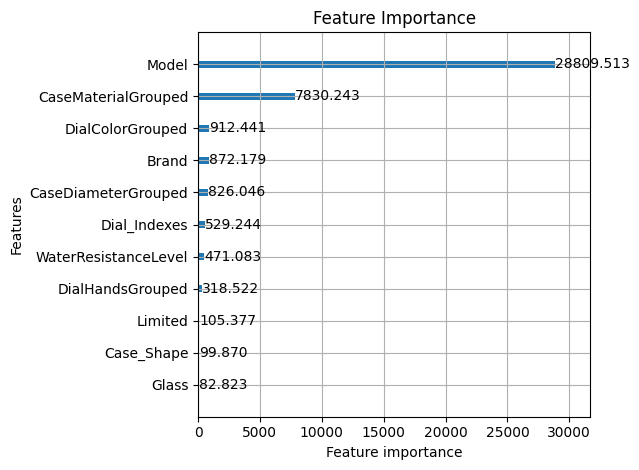

In [27]:
import matplotlib.pyplot as plt

lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.title("Feature Importance")
plt.tight_layout()
plt.show()